In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor




from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error,
)

In [2]:
df = pd.read_csv("housing.csv")

X_full = df.drop(columns="median_house_value")
y_full = df["median_house_value"]

## EDA 

In [3]:
print("X:", X_full.shape, "y:", y_full.shape)
display(df.head())
df.info()
df.isna().sum()

X: (20640, 9) y: (20640,)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Text(0.5, 1.0, 'Distrubution of median_house_value')

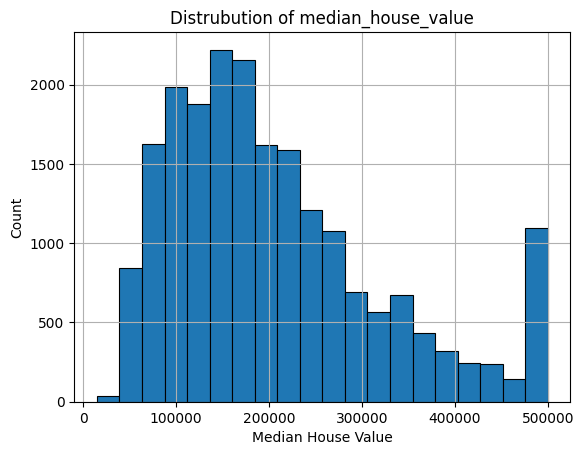

In [4]:
plt.hist(y_full, bins=20, edgecolor="black", linewidth=0.8)
plt.grid(True)
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.title("Distrubution of median_house_value")

In [5]:
y_full.sort_values(ascending=False).head(10)

5253    500001.0
5254    500001.0
5255    500001.0
5256    500001.0
5257    500001.0
5258    500001.0
5259    500001.0
5260    500001.0
5261    500001.0
5262    500001.0
Name: median_house_value, dtype: float64

- Vanligaste medianpriserna ligger runt 100.000 till 200.000.
- Det finns ett tak i datan för medianpriserna vid 500.001.

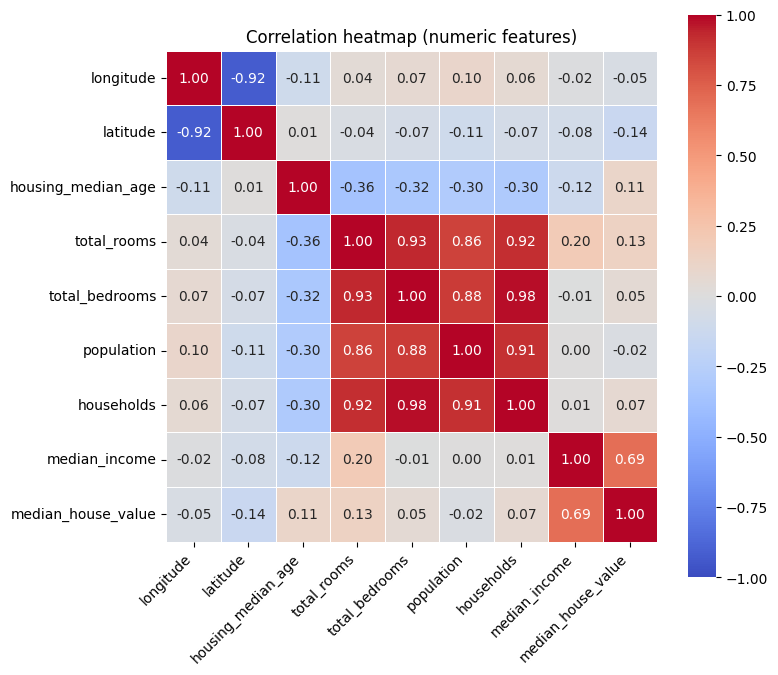

In [6]:
df_num = df.select_dtypes(include="number")

corr = df_num.corr()

plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation heatmap (numeric features)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- median_income har starkast korrelation med median_house_value (≈0.69)
- Övriga numeriska features har relativt svag linjär korrelation med median_house_value
- total_rooms, total_bedrooms, households och population är starkt korrelerade med varandra (≈ 0.86–0.98)

## Split + preprocessing 

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42
)

In [8]:
categorical_features = ["ocean_proximity"]
numeric_features = X_full.columns.drop(categorical_features)



numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

## Modellering

In [9]:
# Baseline

baseline_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_pipe.fit(X_train, y_train)

baseline_predictions_test = baseline_pipe.predict(X_test)

mae = mean_absolute_error(y_test, baseline_predictions_test)
rmse = root_mean_squared_error(y_test, baseline_predictions_test)

print(f"Baseline MAE: {mae:.2f}")
print(f"Baseline RMSE: {rmse:.2f}")

Baseline MAE: 90606.85
Baseline RMSE: 114485.64


In [10]:
# Rigde och Random_forest pipelines

ridge_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(random_state=42))
])

ridge_pipe.fit(X_train, y_train)



random_forest_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        n_jobs=-1
    ))
])

random_forest_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# Jämförelse med crossvalidation

models = {
    "Baseline": baseline_pipe,
    "Ridge": ridge_pipe,
    "RandomForest": random_forest_pipe
}

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

results = []

for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    mae = -cv["test_MAE"].mean()
    rmse = -cv["test_RMSE"].mean()

    results.append({
        "model": name,
        "cv_mae_mean": mae,
        "cv_rmse_mean": rmse
    })

results_df = pd.DataFrame(results).sort_values("cv_mae_mean")
results_df
    

,model,cv_mae_mean,cv_rmse_mean
2,RandomForest,32035.928528,49041.735390
1,Ridge,49665.128165,68621.680654
0,Baseline,91394.674508,115618.556606


- RandomForest presterar bäst i 5-fold cross-validation på träningsdatan med lägst fel: MAE ≈ 32 036 och RMSE ≈ 49 041.
- Ridge är sämre (MAE ≈ 49 665, RMSE ≈ 68 622) och baselin är sämst (MAE ≈ 91 395, RMSE ≈ 115 619).

Därför väljs RandomForest som kandidat för nästa steg

## Justering och optimering

In [12]:
rf_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 10],
    "model__max_features": [0.5, 1]
}


rf_grid_search = GridSearchCV(
    estimator=random_forest_pipe,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)



rf_grid_search.fit(X_train, y_train)


print("Best params:", rf_grid_search.best_params_)
print("Best CV RMSE:", -rf_grid_search.best_score_)  
print("Best model:", rf_grid_search.best_estimator_["model"])



Best params: {'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV RMSE: 48671.35963149766
Best model: RandomForestRegressor(max_depth=20, max_features=0.5, n_estimators=500,
                      n_jobs=-1, random_state=42)


- Jag optimerade RandomForest genom att testa olika värden i hyperparametrarna: n_estimators, max_depth, min_samples_split och max_features. Detta gjordes med GridSearchCV med 5 folds. 

- Jag optimerade mot RMSE för att straffa stora fel mer. Detta anser jag passar bättre för att förutspå huspriser då små fel inte är lika kritiska som stora missar.

Bästa parametrar:
- n_estimators : 500
- max_depth : 20
- min_samples_split : 2
- max_features : 0.5

## Utvärdering på testdata

In [13]:
best_model = rf_grid_search.best_estimator_

y_pred_test = best_model.predict(X_test)

rmse_test = root_mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test MAE:  {mae_test:.2f}")

Test RMSE: 48657.11
Test MAE:  31780.77


In [14]:
def evaluate_regression_model(y_true, y_pred, model_name: str) -> dict:
    
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    return {"model": model_name, "RMSE": rmse, "MAE": mae}


comparison_results = []

comparison_results.append(
    evaluate_regression_model(y_test, baseline_pipe.predict(X_test), "Baseline (mean)")
)

comparison_results.append(
    evaluate_regression_model(y_test, ridge_pipe.predict(X_test), "Ridge")
)

best_model = rf_grid_search.best_estimator_
comparison_results.append(
    evaluate_regression_model(y_test, best_model.predict(X_test), "RandomForest (tuned)")
)

pd.DataFrame(comparison_results).sort_values("RMSE").round(2)

,model,RMSE,MAE
2,RandomForest (tuned),48657.11,31780.77
1,Ridge,70066.02,50676.92
0,Baseline (mean),114485.64,90606.85


Jag rekommenderar att ta vidare RandomForest (tuned) då den presterar bäst på testet i både RMSE (huvudmetrik) och MAE. RandomForest är också bra på att fånga icke-linjära samband vilket kan vara bra då huspriser ofta påverkas av kombinationer av variabler snarare än ett helt linjärt samband.


## PCA

In [15]:
pca_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pca_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

pca_preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)



In [16]:
pca_X = pca_preprocess.fit_transform(X_train)

pca_full = PCA()
pca_X_full = pca_full.fit_transform(pca_X)

explained_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

print("explained variance ratio (first 10):", np.round(explained_ratio[:10], 4))
print("Cumulative explained variance (first 10):", np.round(cum_explained[:10], 4))

explained variance ratio (first 10): [0.4503 0.229  0.1246 0.1014 0.0353 0.0217 0.0163 0.0105 0.0066 0.0027]
Cumulative explained variance (first 10): [0.4503 0.6793 0.8039 0.9053 0.9406 0.9622 0.9786 0.9891 0.9956 0.9983]


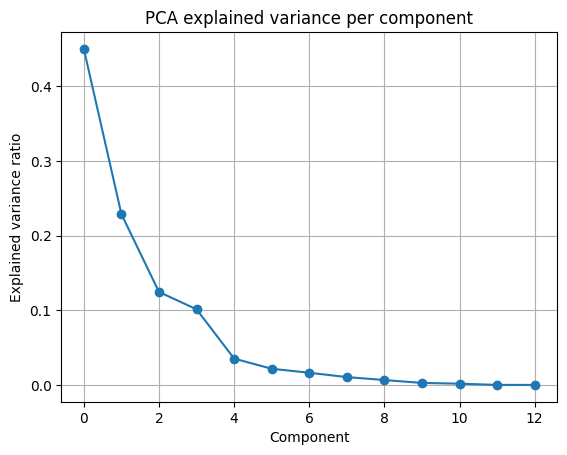

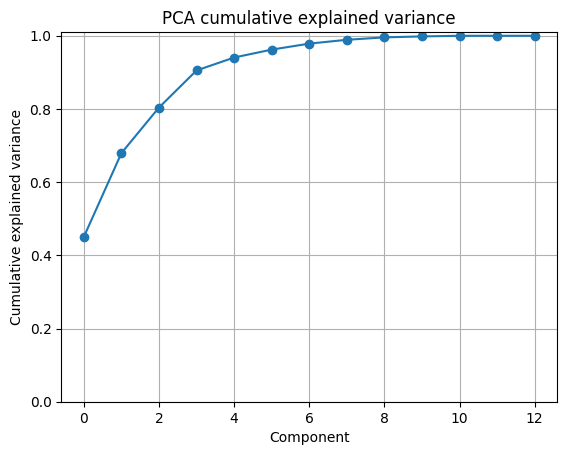

In [17]:
plt.plot(explained_ratio, marker="o")
plt.title("PCA explained variance per component")
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.grid(True)
plt.show()

plt.plot(cum_explained, marker="o")
plt.title("PCA cumulative explained variance")
plt.xlabel("Component")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.ylim(0, 1.01)
plt.show()


- PCA visar att de första 4 komponenterna fångar cirka 90% av den totala variationen. Det tyder på att många features hänger ihop och kan beskrivas med färre dimensioner.
- PCA väljer komponenter som fångar mest spridning i datan och inte alltid vad som är viktigast för huspriset.

## Residualer

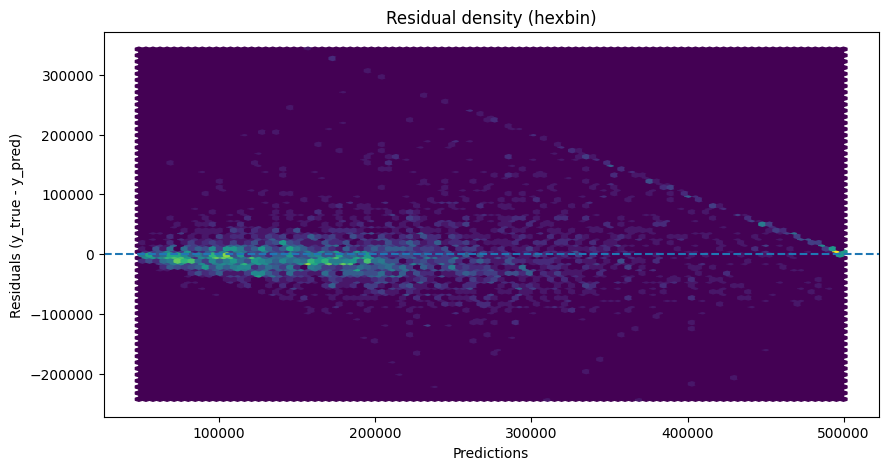

In [18]:
residuals = y_test - y_pred_test

plt.figure(figsize=(10,5))
plt.hexbin(y_pred_test, residuals, gridsize=100) 
plt.axhline(0, linestyle="--")
plt.xlabel("Predictions")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual density (hexbin)")
plt.show()


Modellen presterar bäst vid lägre priser upp till cirka 200.000. Residualerna sprider sig mer vid högre predikterade priser men verkar vara balanserad i att över/underskatta priset. Den skarpa kanten beror förmodligen på taket i datan (500.001).